# Méthode des moindres carrés
La méthode des moindres carrés est utilisée lorsque l'on souhaite ajuster une fonction sur un ensemble de données. Plus précisément, on considère une famille de fonctions $\mathcal F$ dont les éléments $f_a$ dépendent d'un paramètre $a\in{\mathbb R}^d$. Par exemple $\mathcal F=
\{
f_a:{\mathbb R}\to{\mathbb R},x\longmapsto a x
\}$, 
ensemble des fonctions linéaires, paramétrées par un paramètre réel $a\in{\mathbb R}$.

On dispose d'un ensemble de données qu'on suppose etre généré par une fonction de la famille $\mathcal F$, c'est-à-dire qu'il existe un ensemble de points $\{(x_i,y_i)\}_{1\leq i\leq n}$ tel que
$$
\forall i =1\dots n, 
y_i = f_{a_0}(x_i) + \varepsilon_i,$$
où $x_i\in{\mathbb R}^p$ et $y_i\in{\mathbb R}^q, i= 1\dots n$ pour un certain paramètre $a_0$.
La présence de $\varepsilon_i$ peut être due à l'existence d'un bruit d'acquisition (arrondi numérique, erreur ou imprécision) et/ou à l'approximation de la modélisation. 

Le problème est le suivant : étant donné l'ensemble des données $u = \{(x_i,y_i)\}_{1\leq i\leq n}$, quelle est la fonction $f_a\in\mathcal F$ pour laquelle le nuage de points $v_{f_a}=\{(x_i,f_a(x_i))\}_{1\leq i\leq n}$ se rapproche le plus des données? Ces deux ensembles de points appartenant un espace euclidien, on peut mesurer la distance entre ces deux ensembles à l'aide de la distance 
$$\|v_{f_a}-u\|^2 
= \sum_{i=1}^n\|f_a(x_i)-y_i\|_2^2. 
$$
Le problème d'ajustement peut donc s'écrire comme le problème d'optimisation suivant :
$$\displaystyle
\min_{f_a\in\mathcal F} \sum_{i=1}^n\|f_a(x_i)-y_i\|_2^2.
$$
ce qui revient à minimiser l'erreur au carré moyenne entre les données $y_i$ et le modèle théorique $f_a(x_i)$ 
; d'où le nom de méthode des *moindres carrés*. Puisque la famille $\mathcal F$ est paramétrée par le vecteur $a\in{\mathbb R}^d$, la forme finale du problème d'ajustement devient
$$\min_{a\in{\mathbb R}^d} E(a),
$$
où 
$$\hskip 5cm E(a) =\sum_{i=1}^n\|f_a(x_i)-y_i\|_2^2.\hskip 5cm(1)$$

## Regression linéaire
Prenons l'exemple loi d'Ohm, qui stipule qu'il existe une relation linéaire entre l'intensité $I$ (mesurée en ampères) du courant électrique qui traverse un conducteur et la tension $U$ (mesurée en volts) à ses bornes : 
$$U = R I.$$
Le rapport $R$ (constant) entre la tension et l'intensité est appelé *résistance* ( mesurée en Ohms). Afin d'estimer la valeur de la résistance d'un conducteur donné, on peut faire passer un courant d'une intensité connue $I_0$ à travers le conducteur, puis mesurer la tension $U_0$ associée ; enfin, calculer le rapport $U/I$ et en déduire une valeur de résistance. 
Si l'on réitère l'expérience avec une autre valeur d'intensité $I_1$ connue, on *devrait* trouver la même valeur de résistance.
En pratique, ce n'est pas le cas (et ce, même si $I_0=I_1$ !). De nombreux facteurs expliquent une telle différence : le voltmètre utilisé n'est pas suffisamment précis, l'affichage tronque la valeur de la tension, la loi d'Ohm n'est qu'une loi théorique qui *approche* le comportement réel du conducteur... 
Ainsi, si on fait une série de $n$ mesures de tension $U_i$ associées à $n$ valeurs d'intensité connues $I_i$, on a seulement
$$
\forall i=1\dots n, 
U_i \approx R I_i
$$
Pour estimer la valeur de la résistance, nous allons utiliser la méthode des moindres carrés. 

**Exercice.** Régression linéaire en dimension 1.

In [43]:
import numpy as np
import matplotlib.pyplot as plt

- Choisir une valeur réelle $R_{\text{théorique}}$. Générer $n=10$ valeurs d'intensité $I_i$, puis générer $n$ valeurs de tension $U_i$. Pour simuler l'imprécision des $U_i$, on ajoutera à chaque valeur théorique $R_{\text{théorique}} I_i$ un bruit blanc gaussien de variance $\sigma$ à choisir.

In [44]:
Rtheo = 8.5 # ohm, a vous de choisir
n = 10
I_min, I_max = 0, 1.5 # bornes pour les valeurs d'intensite
I = I_min + ( I_max - I_min ) *np.random.rand(n) # generer des valeurs d'intensite entre I_min et I_max
# a vous de jouer pour generer U
sigma = 0.1
U = Rtheo*I+sigma * np.random.randn(n)

print(f" I = {I}, U = {U}")

 I = [0.23399178 0.08712542 1.29926422 0.90167252 1.06210887 0.03087674
 1.45486478 1.24866396 0.31850867 0.27273745], U = [ 1.93179212  0.64815777 10.78249096  7.75925337  9.10956987  0.1100647
 12.32354601 10.53940299  2.63698928  2.10430627]


- Donner l'expression de la fonction à minimiser selon la méthode des moindres carrés? (Sur papier ou dans une cellule "markdown")

La fonction à minimiser est :

$E(R) = \sum_{i=1}^n (U_i - R I_i)^2$


- Donner l'expression de la résistance optimale $R_{opt}$ donnée par la méthode des moindres
carrés. (Sur papier ou dans une cellule "markdown")



On dérive $E(R)$ par rapport à R et on annule :

$dE/dR = -2 \sum I_i (U_i - R I_i) = 0$

Donc :

$R_opt = \frac{\sum_{i=1}^n U_i I_i}{\sum_{i=1}^n I_i^2}$

- Comparer numériquement la valeur de $R_{\text{théorique}}$ et $R_{opt}$

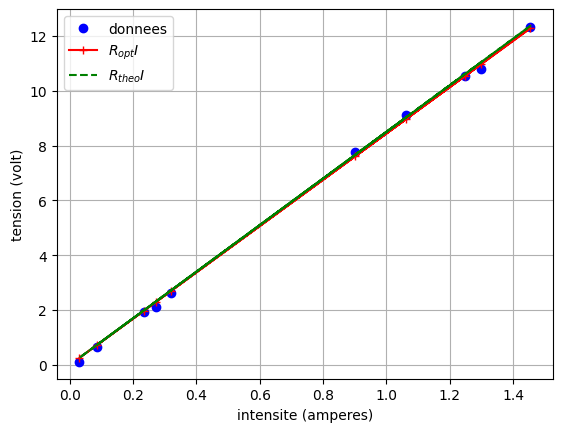

R theorique : 8.5
R optimal   : 8.443148693312711


In [45]:
# Calcul de Ropt
Ropt = np.sum(U * I) / np.sum(I**2)

# Affichage
plt.plot(I, U, 'ob', label='donnees')
plt.plot(I, Ropt * I, '+-r', label='$R_{opt} I$')
plt.plot(I, Rtheo * I, '--g', label='$R_{theo} I$')
plt.xlabel('intensite (amperes)')
plt.ylabel('tension (volt)')
plt.legend()
plt.grid()
plt.show()

print(f'R theorique : {Rtheo}')
print(f'R optimal   : {Ropt}')

**Reprendre les questions précédentes avec un niveau de bruit $\sigma$ plus important. Qu'en pensez-vous?**


Lorsque le bruit σ augmente :
- L’écart entre R_opt et R_theorique augmente.
- L’estimation devient moins précise.
- La variance de l’estimateur augmente.
 
- Reprendre les questions précédentes avec moins de points de données ($n = 5$ par exemple). Qu'en pensez vous?


Avec moins de points :

- L’estimation est plus instable.
- R_opt varie davantage selon les tirages.
- L’erreur augmente en moyenne.

**Reproductibilité des expériences numériques utilisant des valeurs pseudo aléatoires. Remarquez en exécutant plusieurs fois la cellule précédente que l'appel à une fonction du package numpy.random renvoie à chaque fois des valeurs différentes.**

Exécutez plusieurs fois les deux blocs de code ci-dessous, et donnez un exemple où la deuxième version pourrait être utile

La deuxième version est utile lorsque l’on veut reproduire exactement les mêmes expériences numériques (par exemple pour un article scientifique, un rapport ou un contrôle).

In [48]:
help(np.random.seed)

Help on cython_function_or_method in module numpy.random:

seed(seed=None)
    seed(seed=None)

    Reseed the singleton RandomState instance.

    Notes
    -----
    This is a convenience, legacy function that exists to support
    older code that uses the singleton RandomState. Best practice
    is to use a dedicated ``Generator`` instance rather than
    the random variate generation methods exposed directly in
    the random module.

    See Also
    --------
    numpy.random.Generator



In [49]:
help(np.random.RandomState)

Help on class RandomState in module numpy.random.mtrand:

class RandomState(builtins.object)
 |  RandomState(seed=None)
 |
 |  Container for the slow Mersenne Twister pseudo-random number generator.
 |  Consider using a different BitGenerator with the Generator container
 |  instead.
 |
 |  `RandomState` and `Generator` expose a number of methods for generating
 |  random numbers drawn from a variety of probability distributions. In
 |  addition to the distribution-specific arguments, each method takes a
 |  keyword argument `size` that defaults to ``None``. If `size` is ``None``,
 |  then a single value is generated and returned. If `size` is an integer,
 |  then a 1-D array filled with generated values is returned. If `size` is a
 |  tuple, then an array with that shape is filled and returned.
 |
 |  **Compatibility Guarantee**
 |
 |  A fixed bit generator using a fixed seed and a fixed series of calls to
 |  'RandomState' methods using the same parameters will always produce the
 | 

In [50]:
import numpy as np
np.random.seed(42)  
valeurs = np.random.rand(5)  
print(valeurs)

[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]


In [51]:
import numpy as np
rng = np.random.RandomState(42)
valeurs = rng.rand(5)
print(valeurs)

[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]


## Régression polynomiale
On suppose maintenant que l'on dispose de $n$ couples de données $(x_i, y_i) \in {\mathbb R}^2$ satisfaisant :
$\forall i = 1 \dots n, y_i = P(x_i) +\varepsilon_i,$
avec $P$ un polynôme réel de degré au plus $p$. Nous rappelons que tout tel polynôme est défini de manière unique par un vecteur $a = (a_k)_{0\leq k\leq p} \in {\mathbb R}^{p+1}$ :
$$P(X) = \sum_{k=0}^p a_k X^k$$
On suppose connaître les couples de données $(x_i, y_i)$ et on cherche un polyn{o}me qui approche au mieux ces données.

**Exercice.** Régression polynomiale.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

- Choisir un vecteur $a \in {\mathbb R}^6$. Soit $P$ le polynôme associé. Générer $n=10$ valeurs $x_i$, puis $n$ valeur $y_i = P(x_i) + \varepsilon_i$ avec $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$, pour une valeur $\sigma$ de votre choix.

In [54]:
# Choix des coefficients du polynome P de degre p = 5
p = 5
c1, c2 = -10, 10
coef = c1 + (c2 - c1) * np.random.rand(p + 1)

# Generation des donnees
n = 10
a, b = -2, 2
x = a + (b - a) * np.random.rand(n)
x.sort()

# Calcul de P(x) 
Px = np.zeros(n)
for k in range(len(coef)):
    Px = Px + coef[k] * x**k

# Ajout du bruit
sigma = 0.5
y = Px + sigma * np.random.randn(n)

- Ecrire sur papier le problème d'ajustement au sens des moindres carrés. Le reformuler en introduisant la matrice $X \in \mathcal{M}_{n,p+1}({\mathbb R})$ définie par $X_{i,k} = x_i^k$.

- Le problème a-t-il une solution? Cette solution est elle unique? (Sur papier)

- Réaliser l'ajustement polynomial pour des degrés $p = 0, 1, \cdots, 6$.


On cherche à minimiser :

$E(a) = \sum_{i=1}^n (y_i - \sum_{k=0}^p a_k x_i^k)^2$

En introduisant la matrice X définie par :

$X_{i,k} = x_i^k$

Le problème devient :

$min_a ||Y - Xa||^2$


Le problème admet une solution si X^T X est inversible.

La solution est unique si les colonnes de X sont linéairement indépendantes (ce qui est le cas si les x_i sont distincts et n > p).


In [63]:
# Formation de la matrice X telle que X[i, k] = x_i^k
X = np.zeros((n, p + 1))
for k in range(p + 1):
    X[:, k] = x**k

# Résolution des équations normales
a_opt = np.linalg.solve(X.T @ X, X.T @ y)

print("Coefficients optimaux :", a_opt)


Coefficients optimaux : [ 1.99998794e+00 -1.00000352e+00  3.00037215e-01 -4.00000909e+00
  2.99977049e-01  2.38667500e-06  3.08257575e-06]


- Afficher sur le même graphique le nuage de points $(x_i , y_i)$, le polynôme $P$ théorique et les 7 ajustements polynomiaux.

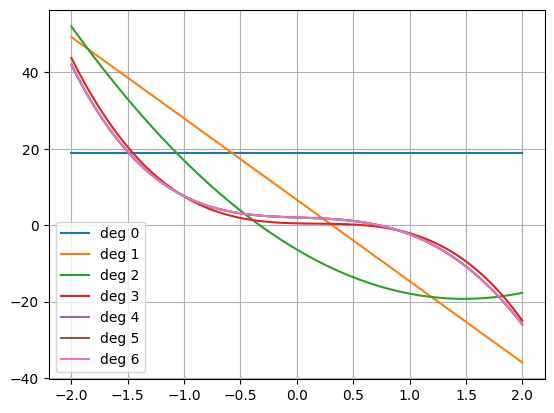

In [64]:
# Pour tracer le polynome sur plus de points
x_precis = np.linspace(a, b, 100)

for p in range(7):
    # Construction matrice X
    X = np.zeros((n, p + 1))
    for k in range(p + 1):
        X[:, k] = x**k
    
    # Résolution moindres carrés
    a_opt = np.linalg.solve(X.T @ X, X.T @ y)
    
    # Evaluation sur grille fine
    P_fit = np.zeros_like(x_precis)
    for k in range(p + 1):
        P_fit += a_opt[k] * x_precis**k
    
    plt.plot(x_precis, P_fit, label=f'deg {p}')

plt.legend()
plt.grid()
plt.show()


**Exercice.** $ $
Proposer une méthode des moindres carrés et l'implémenter pour approcher les données suivantes

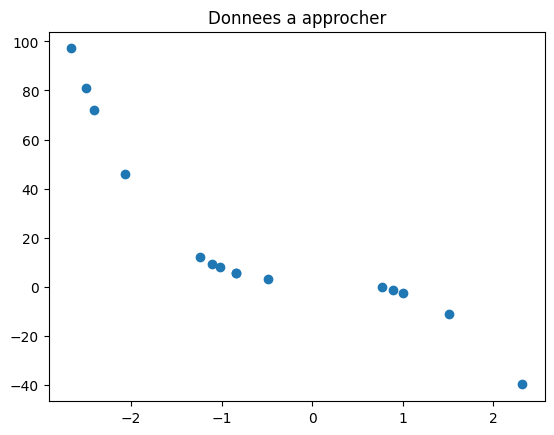

In [57]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([-2.6605, -2.5024, -2.4075, -2.0656, -1.2418, -1.1105,
-1.0194, -0.8459, -0.8403, -0.4906,  0.7695,  0.8933,  1.0023,  
1.5085, 2.3193])
y = np.array([ 97.1414, 80.8250, 72.0406, 46.0602, 12.0776, 9.4146, 
7.8925, 5.6353, 5.5751, 3.0525, -0.3093, -1.3142, -2.4258, 
-11.0032, -39.9284])

n = len(x)
plt.plot(x, y, 'o')
plt.title('Donnees a approcher')
plt.show()

On fera varier le degré du polynôme de $1$ à $6$. 

- Quel est le degré du polynôme qui approche au mieux les données ? Que vaut l'erreur définie en (1) ?

In [66]:
erreurs = []

for p in range(1, 7):
    # Matrice X
    X = np.zeros((n, p + 1))
    for k in range(p + 1):
        X[:, k] = x**k
    
    # Résolution
    a_opt = np.linalg.solve(X.T @ X, X.T @ y)
    
    # Prédictions
    y_pred = X @ a_opt
    
    # Erreur quadratique
    erreur = np.sum((y - y_pred)**2)
    erreurs.append(erreur)
    
    print(f"Degré {p} — Erreur : {erreur:.4f}")

degre_optimal = np.argmin(erreurs) + 1
print(f"\nDegré optimal : {degre_optimal}")


Degré 1 — Erreur : 4596.2976
Degré 2 — Erreur : 2254.4523
Degré 3 — Erreur : 9.9341
Degré 4 — Erreur : 0.0000
Degré 5 — Erreur : 0.0000
Degré 6 — Erreur : 0.0000

Degré optimal : 6


- Comparer votre résultat avec celui obtenu avec la fonction `polyfit` du module `numpy`. Voir l'aide de `numpy` pour l'utilisation de cette fonction.

In [67]:
p_opt = degre_optimal

coef_polyfit = np.polyfit(x, y, p_opt)

print("Coefficients polyfit :", coef_polyfit)


Coefficients polyfit : [ 3.08257556e-06  2.38667478e-06  2.99977049e-01 -4.00000909e+00
  3.00037215e-01 -1.00000352e+00  1.99998794e+00]


**Exercice.** Régression linéaire multivariée.

On dispose de mesures de barres de métal : leur hauteur $h$, longueur $\ell$, largeur $w$ (en mètres) ainsi que leur poids $p$ (en kilogrammes). On souhaite prédire le poids d'une barre à partir de ses trois dimensions.

In [69]:
pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.7 MB 20.9 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.7 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 21.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Questions théoriques
On modélise le poids par une fonction affine des trois dimensions :
$$p = a_1 h + a_2 \ell + a_3 w + a_0$$
où $a_0, a_1, a_2, a_3 \in \mathbb{R}$ sont les paramètres à déterminer.

- On dispose de $n$ mesures $(h_i, \ell_i, w_i, p_i)_{i=1,...,n}$. Écrire le problème des moindres carrés associé : on cherche à minimiser 
$$\mathcal{L}(a_0, a_1, a_2, a_3) = \sum_{i=1}^{n} \left( p_i - (a_1 h_i + a_2 \ell_i + a_3 w_i + a_0) \right)^2.$$

- Poser $a = (a_1, a_2, a_3, a_0)^T \in \mathbb{R}^4$, $Y = (p_1, ..., p_n)^T \in \mathbb{R}^n$ et construire la matrice $X \in \mathbb{R}^{n \times 4}$ telle que le problème s'écrive 
$$\min_{a \in \mathbb{R}^4} \| Y - X a \|^2.$$

- Rappeler les équations normales et la solution $a^*$ du problème.

### Application à la base de données 1

- Charger la base de données `database_1.csv` avec `pandas`.

In [74]:
df1 = pd.read_csv('database_1.csv')
print(df1.columns) # affiche les en-tetes de colonne
print(df1.head())  # affiche les premieres lignes
print(df1.describe())  # resume statistique

Index(['height', 'length', 'width', 'weight'], dtype='str')
      height    length     width      weight
0   9.672340  0.962827  0.009874  128.734139
1   9.507188  1.020853  0.006968   94.679105
2  10.815520  1.012724  0.008866  135.950539
3   9.128141  0.964485  0.008231  101.450331
4  10.013902  1.031749  0.007110  102.838743
           height      length       width      weight
count  100.000000  100.000000  100.000000  100.000000
mean    10.023638    0.996169    0.010200  142.605531
std      0.582560    0.028434    0.002865   41.196753
min      9.035658    0.950124    0.005205   68.247292
25%      9.504702    0.971977    0.007893  103.108581
50%     10.010892    0.989462    0.009954  140.308060
75%     10.559888    1.018768    0.012667  179.428107
max     10.983453    1.049933    0.014879  223.035378


- Construire la matrice $X$ et le vecteur $Y$ à partir des données.

In [75]:
# Extraction des colonnes
h = df1['height'].values
l = df1['length'].values
w = df1['width'].values
Y = df1['weight'].values

n = len(Y)

# Matrice X avec constante
X = np.column_stack((h, l, w, np.ones(n)))


- Résoudre les équations normales pour trouver $a^*$.

In [76]:
a_opt = np.linalg.solve(X.T @ X, X.T @ Y)

print("Coefficients optimaux :")
print(f"a1 (height)  = {a_opt[0]}")
print(f"a2 (length)  = {a_opt[1]}")
print(f"a3 (width)   = {a_opt[2]}")
print(f"a0 (const)   = {a_opt[3]}")


Coefficients optimaux :
a1 (height)  = 13.93620115821904
a2 (length)  = 125.80489333650767
a3 (width)   = 13983.854435606183
a0 (const)   = -265.04441419960426


- Calculer les prédictions $\hat{p}_i = a_1^* h_i + a_2^* \ell_i + a_3^* w_i + a_0^*$ et l'erreur quadratique moyenne :
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{p}_i - p_i)^2.$$

In [77]:
Y_pred = X @ a_opt

MSE = np.mean((Y_pred - Y)**2)

print(f"MSE = {MSE}")


MSE = 8.002091636964984


- L'erreur MSE est-elle parlante ? Proposer une mesure d'erreur plus interpretable (par exemple l'erreur relative moyenne ou l'écart-type de l'erreur). Commenter.

In [78]:
# Erreur relative moyenne
erreur_relative = np.mean(np.abs((Y_pred - Y) / Y))

# RMSE
RMSE = np.sqrt(MSE)

print(f"Erreur relative moyenne : {erreur_relative}")
print(f"RMSE : {RMSE}")


Erreur relative moyenne : 0.017019441776040315
RMSE : 2.828796853251393


### Application à la base de données 2

- Charger la base de données `database_2.csv` et effectuer la même régression.

In [84]:
df2 = pd.read_csv('database_2.csv')
# A vous de jouer !
h2 = df2['height'].values
l2 = df2['length'].values
w2 = df2['width'].values
Y2 = df2['weight'].values

n2 = len(Y2)

X2 = np.column_stack((h2, l2, w2, np.ones(n2)))

a_opt2 = np.linalg.solve(X2.T @ X2, X2.T @ Y2)

Y2_pred = X2 @ a_opt2
MSE2 = np.mean((Y2_pred - Y2)**2)

print("Coefficients base 2 :", a_opt2)
print("MSE base 2 :", MSE2)



Coefficients base 2 : [ 4494.53730841   554.36098783  2806.66694689 -4470.36171135]
MSE base 2 : 9.398164972750871


- Comparer les coefficients obtenus avec ceux de la base 1. Les valeurs sont-elles proches ? Commenter.

- Comparer les erreurs obtenues sur les deux bases. Qu'observez-vous ?

### Fusion des bases de données

- Fusionner les deux bases de données et refaire la régression.

In [81]:
df = pd.concat([df1, df2], ignore_index=True)
print(f'Nombre total de donnees : {len(df)}')
# A vous de jouer !

h = df['height'].values
l = df['length'].values
w = df['width'].values
Y = df['weight'].values

n = len(Y)

X = np.column_stack((h, l, w, np.ones(n)))

a_opt_fusion = np.linalg.solve(X.T @ X, X.T @ Y)

Y_pred = X @ a_opt_fusion
MSE_fusion = np.mean((Y_pred - Y)**2)

print("Coefficients fusion :", a_opt_fusion)
print("MSE fusion :", MSE_fusion)


Nombre total de donnees : 234
Coefficients fusion : [  24.07054139  146.26367447 2393.56525488 -268.98586333]
MSE fusion : 4073.0110615650033


- Ayant plus de données, à quoi s'attend-on pour l'erreur ? Qu'observe-t-on ? Commenter.

### Amélioration de la régression

- La régression linéaire donne-t-elle des résultats satisfaisants ? Physiquement, quelle relation attendriez-vous entre le poids d'une barre de métal et ses dimensions ? 

Proposer une transformation des variables d'entrée qui pourrait améliorer la prédiction. Tester votre idée et commenter les résultats.

In [82]:
# A vous de jouer !
# Nouvelle variable : volume
volume = h * l * w

X_new = np.column_stack((volume, np.ones(n)))

a_new = np.linalg.solve(X_new.T @ X_new, X_new.T @ Y)

Y_new_pred = X_new @ a_new
MSE_new = np.mean((Y_new_pred - Y)**2)

print("Modele volume uniquement")
print("Coefficients :", a_new)
print("MSE :", MSE_new)


Modele volume uniquement
Coefficients : [1.40000046e+03 1.10267122e-05]
MSE : 1.2579520708023629e-07
